First 5 rows:
  Student Department  Marks  Attendance  StudyHours
0    Arun        CSE     85          92           5
1    Bala         IT     78          88           4
2  Charan        CSE     92          95           6
3   Divya        ECE     74          82           3
4   Elena         IT     88          91           5

Missing values:
Student       0
Department    0
Marks         0
Attendance    0
StudyHours    0
dtype: int64

Summary Statistics:
           Marks  Attendance  StudyHours
count   8.000000    8.000000    8.000000
mean   84.500000   90.500000    4.875000
std     7.030546    4.566962    1.246423
min    74.000000   82.000000    3.000000
25%    80.250000   88.750000    4.000000
50%    84.000000   90.500000    5.000000
75%    89.000000   92.750000    5.250000
max    95.000000   97.000000    7.000000

Department Summary:
  Department      Marks  Attendance
0        CSE  90.666667   94.666667
1        ECE  77.500000   85.500000
2         IT  83.000000   89.666667


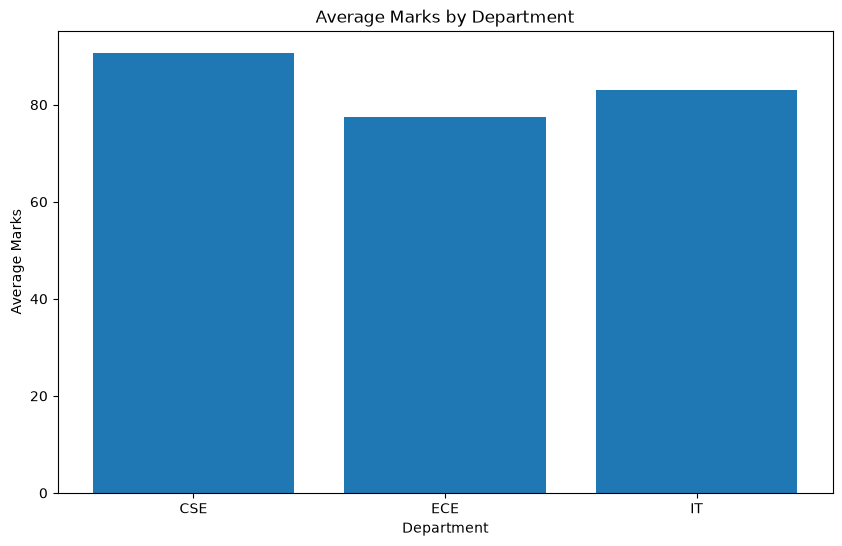

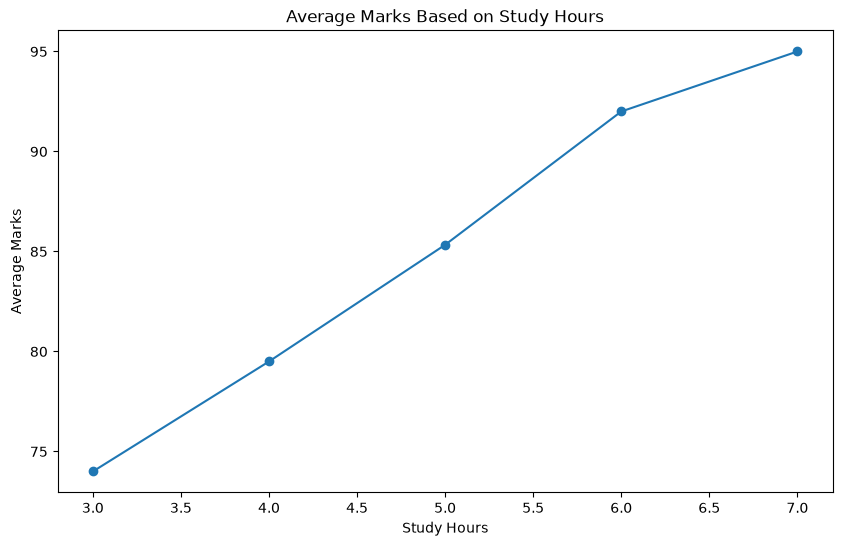


Pivot Table:
StudyHours     3     4     5     6     7
Department                              
CSE          0.0   0.0  85.0  92.0  95.0
ECE         74.0  81.0   0.0   0.0   0.0
IT           0.0  78.0  85.5   0.0   0.0

Correlation Matrix:
               Marks  Attendance  StudyHours
Marks       1.000000    0.961035    0.969983
Attendance  0.961035    1.000000    0.966206
StudyHours  0.969983    0.966206    1.000000


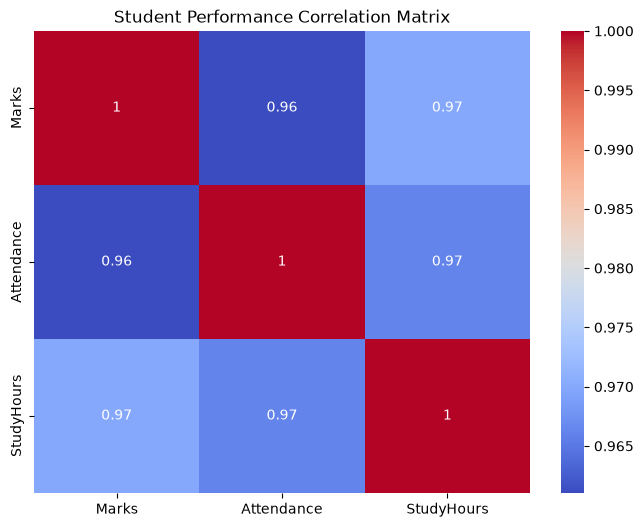

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('student_data.csv')

print("First 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

df['Marks'] = df['Marks'].fillna(df['Marks'].mean())

df.dropna(subset=['Student', 'Department', 'Attendance'], inplace=True)


print("\nSummary Statistics:")
print(df.describe())

department_summary = df.groupby('Department').agg({
    'Marks': 'mean',
    'Attendance': 'mean'
}).reset_index()

print("\nDepartment Summary:")
print(department_summary)

plt.figure(figsize=(10, 6))
plt.bar(department_summary['Department'],
        department_summary['Marks'])

plt.xlabel('Department')
plt.ylabel('Average Marks')
plt.title('Average Marks by Department')
plt.show()

study_summary = df.groupby('StudyHours')['Marks'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(study_summary['StudyHours'],
         study_summary['Marks'],
         marker='o')

plt.xlabel('Study Hours')
plt.ylabel('Average Marks')
plt.title('Average Marks Based on Study Hours')
plt.show()

pivot_table = df.pivot_table(
    values='Marks',
    index='Department',
    columns='StudyHours',
    aggfunc='mean',
    fill_value=0
)

print("\nPivot Table:")
print(pivot_table)

correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm')

plt.title('Student Performance Correlation Matrix')
plt.show()